In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [2]:
PROJECT_ROOT = Path().absolute().parent if Path().absolute().name == 'processors' else Path().absolute()
os.chdir(PROJECT_ROOT)
print(os.getcwd())

/Users/phatvu/Documents/Dev-Drive-Local/crypto-price-forecaster-glm


In [3]:
# Import project configuration
import sys
sys.path.append('.')
from config import *

In [4]:
EPS = 1e-8

In [5]:
master_dataset_path = Path(get_cleaned_dataset_file())
master_df = pd.read_pickle(master_dataset_path)
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17059 entries, 0 to 17058
Data columns (total 60 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   timestamp                            17059 non-null  datetime64[ns]
 1   BTC_open                             17059 non-null  float64       
 2   BTC_high                             17059 non-null  float64       
 3   BTC_low                              17059 non-null  float64       
 4   BTC_close                            17059 non-null  float64       
 5   BTC_volume                           17059 non-null  float64       
 6   BTC_quote_volume                     17059 non-null  float64       
 7   BTC_trades                           17059 non-null  float64       
 8   ETH_open                             17059 non-null  float64       
 9   ETH_high                             17059 non-null  float64       
 10  ETH_low   

In [6]:
final_features = []

## OHLCV

### Build Target

In [7]:
master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])
master_df = master_df.sort_values('timestamp').reset_index(drop=True)
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17059 entries, 0 to 17058
Data columns (total 60 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   timestamp                            17059 non-null  datetime64[ns]
 1   BTC_open                             17059 non-null  float64       
 2   BTC_high                             17059 non-null  float64       
 3   BTC_low                              17059 non-null  float64       
 4   BTC_close                            17059 non-null  float64       
 5   BTC_volume                           17059 non-null  float64       
 6   BTC_quote_volume                     17059 non-null  float64       
 7   BTC_trades                           17059 non-null  float64       
 8   ETH_open                             17059 non-null  float64       
 9   ETH_high                             17059 non-null  float64       
 10  ETH_low   

In [8]:
master_df['BTC_log_return'] = np.log(master_df['BTC_close'] / master_df['BTC_close'].shift(1))
master_df['ETH_log_return'] = np.log(master_df['ETH_close'] / master_df['ETH_close'].shift(1))

#### Stationarity Check

In [9]:
def adf_plot(series, name, ax, alpha=0.05):
    result = adfuller(series.dropna())
    stat, pval = result[0], result[1]
    series.plot(ax=ax, title=f"{name}")
    ax.axhline(0, color="gray", lw=1, ls="--")
    txt = f"ADF: {stat:.2f}\np-value: {pval:.2g}"
    ax.text(0.86, 0.03, txt, transform=ax.transAxes, va="bottom",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    return pval < alpha

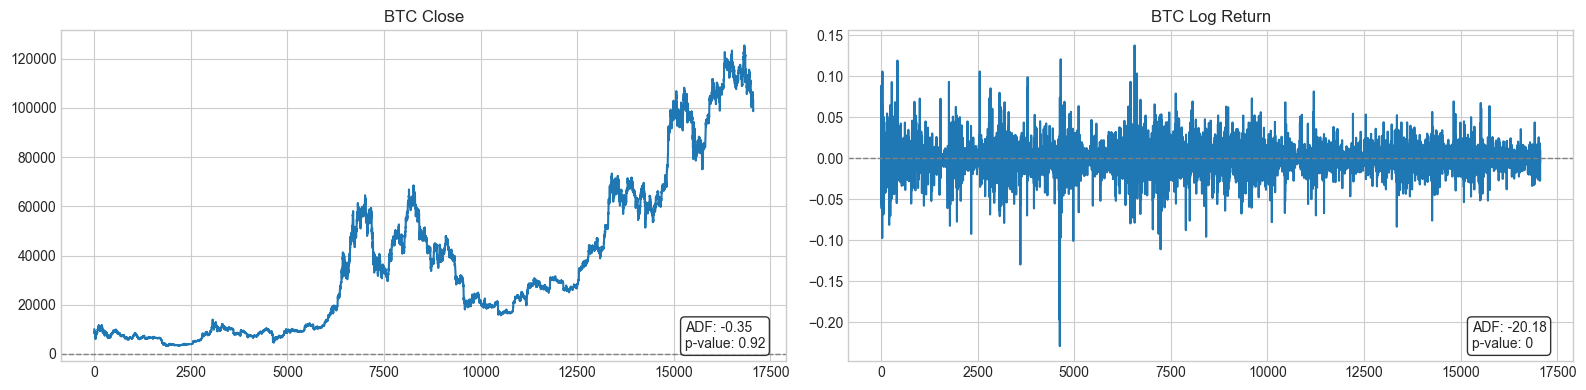

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=False)
price_stationary_BTC = adf_plot(master_df['BTC_close'], "BTC Close", axes[0])
return_stationary_BTC = adf_plot(master_df['BTC_log_return'], "BTC Log Return", axes[1])
plt.tight_layout()
plt.show()

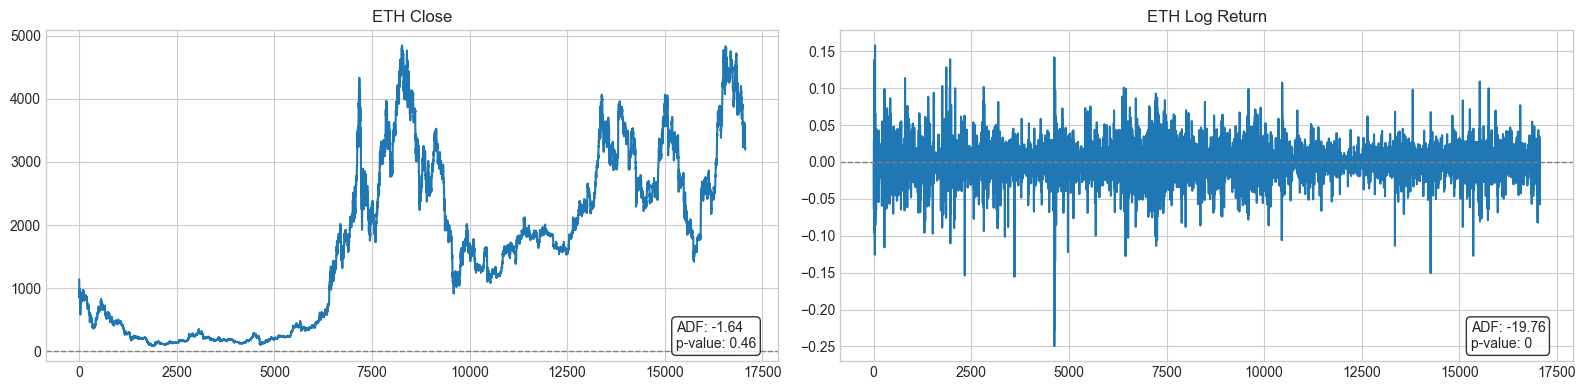

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=False)
price_stationary_ETH = adf_plot(master_df['ETH_close'], "ETH Close", axes[0])
return_stationary_ETH = adf_plot(master_df['ETH_log_return'], "ETH Log Return", axes[1])
plt.tight_layout()
plt.show()

#### Distribution

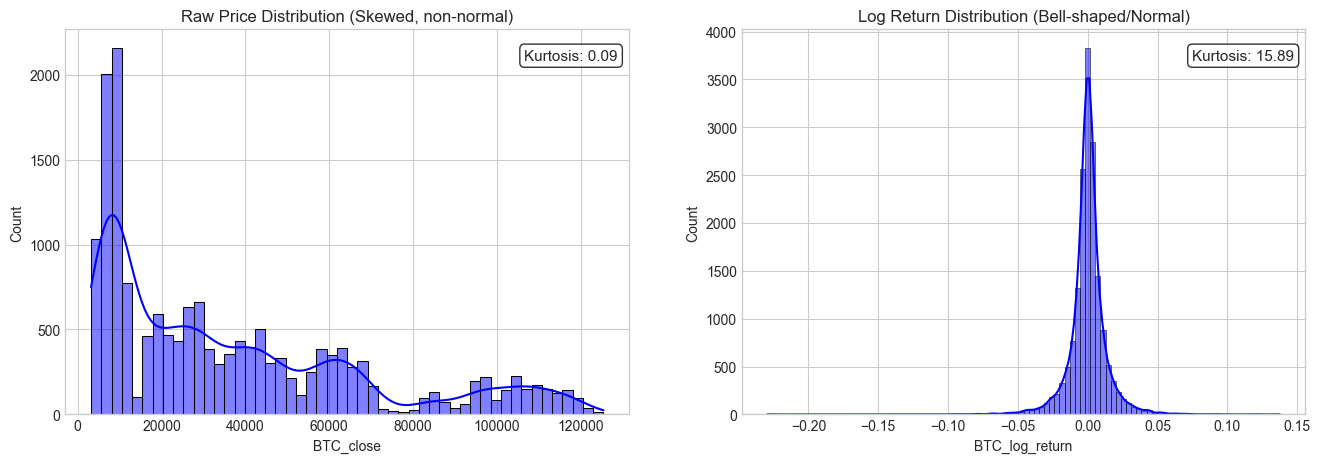

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

k_close = master_df['BTC_close'].kurtosis()
k_log_return = master_df['BTC_log_return'].kurtosis()

# Raw Price Distribution
sns.histplot(master_df['BTC_close'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Raw Price Distribution (Skewed, non-normal)')
ax[0].text(0.98, 0.95, f"Kurtosis: {k_close:.2f}", transform=ax[0].transAxes,
           ha="right", va="top", fontsize=11, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# Log Return Distribution
sns.histplot(master_df['BTC_log_return'], bins=100, kde=True, ax=ax[1], color='blue')
ax[1].set_title('Log Return Distribution (Bell-shaped/Normal)')
ax[1].text(0.98, 0.95, f"Kurtosis: {k_log_return:.2f}", transform=ax[1].transAxes,
           ha="right", va="top", fontsize=11, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.show()

In [13]:
# Build target variable
master_df['target'] = master_df['BTC_log_return'].shift(-1)

In [14]:
final_features.extend(["BTC_log_return", "ETH_log_return", "target"])

### Volume

In [15]:
# Volume log-return (Momentum Volume)
master_df['log_volume'] = np.log1p(master_df['BTC_volume'])

master_df['BTC_vol_log_return'] = (
    master_df['log_volume'] - 
    master_df['log_volume'].shift(1)
)

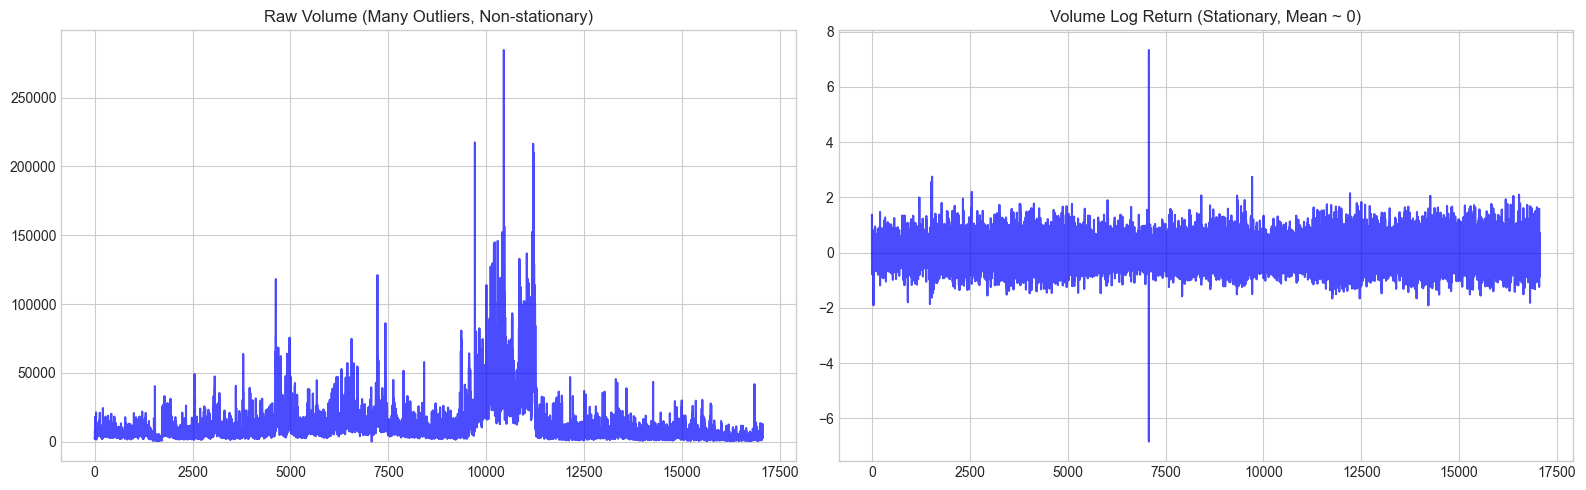

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(master_df.index, master_df['BTC_volume'], color='blue', alpha=0.7)
ax[0].set_title('Raw Volume (Many Outliers, Non-stationary)')

ax[1].plot(master_df.index, master_df['BTC_vol_log_return'], color='blue', alpha=0.7)
ax[1].set_title('Volume Log Return (Stationary, Mean ~ 0)')

plt.tight_layout()
plt.show()

In [17]:
master_df['vol_ma20'] = (
    master_df['BTC_volume']
    .rolling(20)
    .mean()
    .shift(1) 
)

master_df['rvol'] = master_df['BTC_volume'] / (master_df['vol_ma20'] + EPS)
master_df['log_rvol'] = np.log(master_df['rvol'] + EPS)

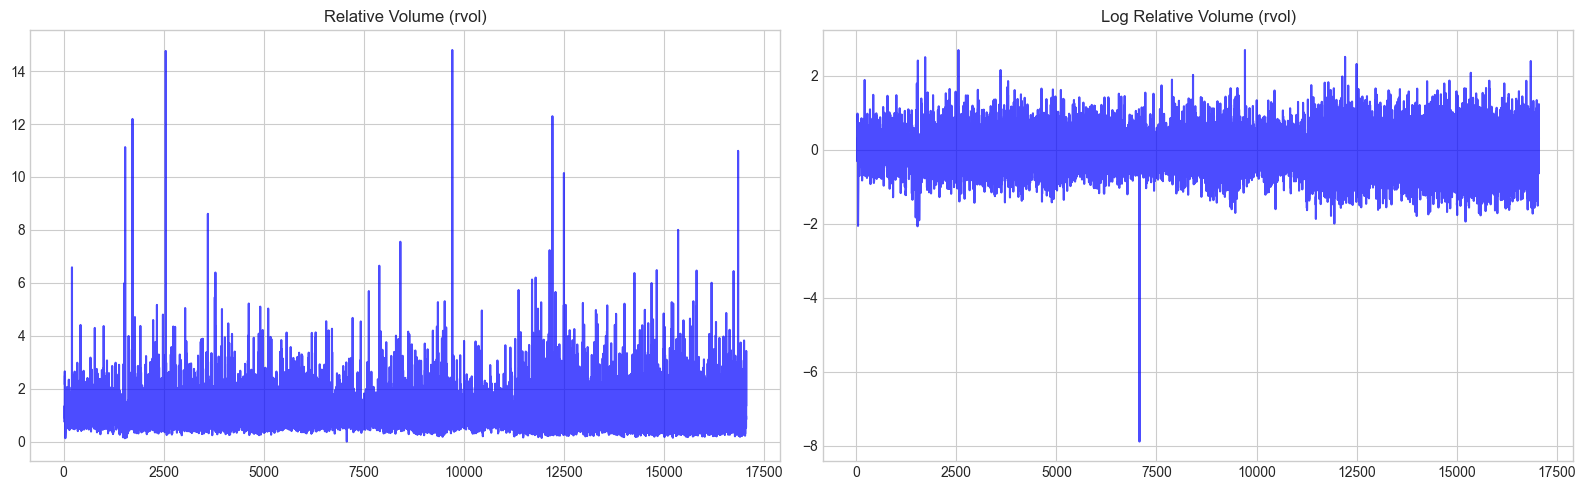

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(master_df.index, master_df['rvol'], color='blue', alpha=0.7)
ax[0].set_title('Relative Volume (rvol)')

ax[1].plot(master_df.index, master_df['log_rvol'], color='blue', alpha=0.7)
ax[1].set_title('Log Relative Volume (rvol)')

plt.tight_layout()
plt.show()

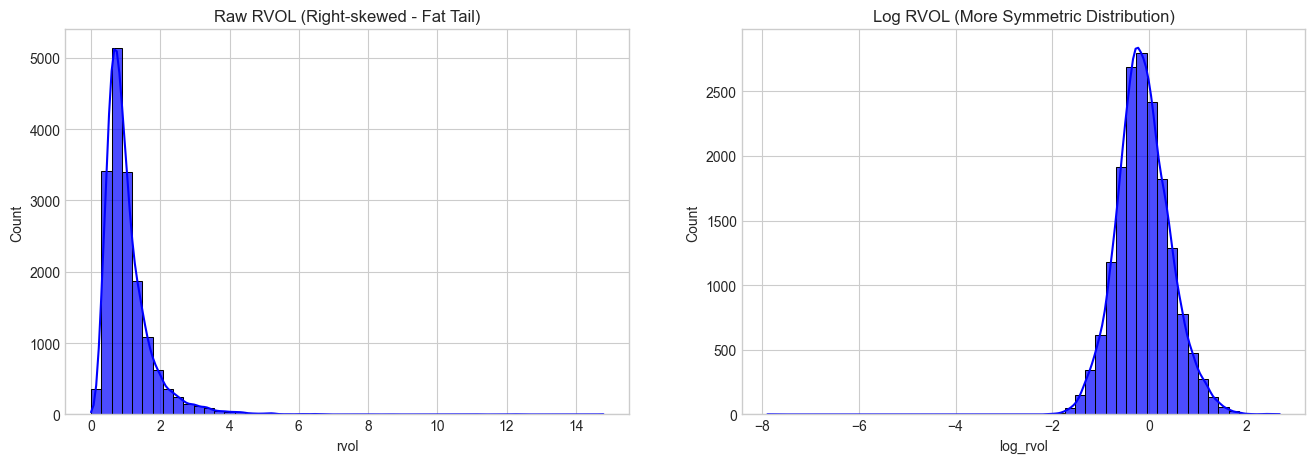

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(master_df['rvol'], bins=50, kde=True, ax=ax[0], color='blue', alpha=0.7)
ax[0].set_title('Raw RVOL (Right-skewed - Fat Tail)')

sns.histplot(master_df['log_rvol'], bins=50, kde=True, ax=ax[1], color='blue', alpha=0.7)
ax[1].set_title('Log RVOL (More Symmetric Distribution)')

plt.show()

In [20]:
final_features.extend(["BTC_vol_log_return", "log_rvol"])

<cell_type>markdown</cell_type>
### Volatility

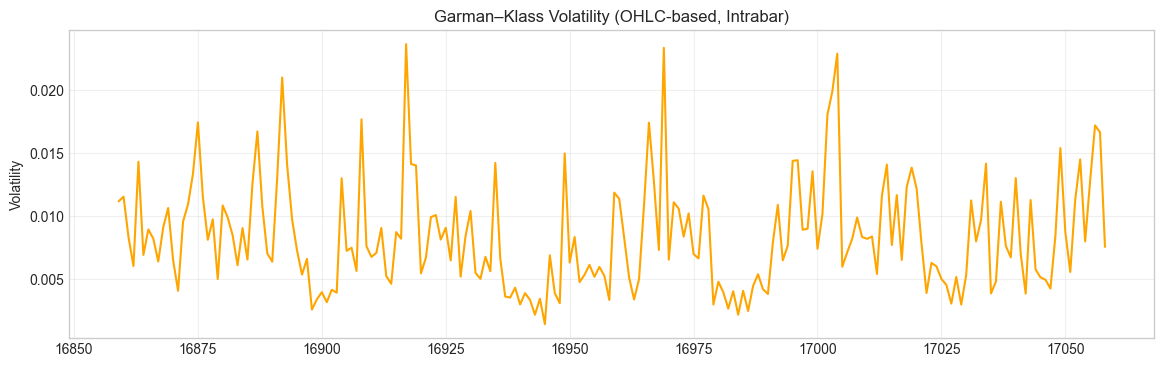

In [21]:
# Garman–Klass Realized Volatility
log_hl = np.log(master_df['BTC_high'] / master_df['BTC_low']) ** 2
log_co = np.log(master_df['BTC_close'] / master_df['BTC_open']) ** 2

rv_gk = 0.5 * log_hl - (2 * np.log(2) - 1) * log_co
master_df['vol_gk'] = np.sqrt(np.maximum(rv_gk, 0))

subset = master_df.iloc[-200:].copy()

plt.figure(figsize=(14, 4))
plt.plot(subset.index, subset['vol_gk'], color='orange')
plt.title('Garman–Klass Volatility (OHLC-based, Intrabar)')
plt.ylabel('Volatility')
plt.grid(alpha=0.3)
plt.show()

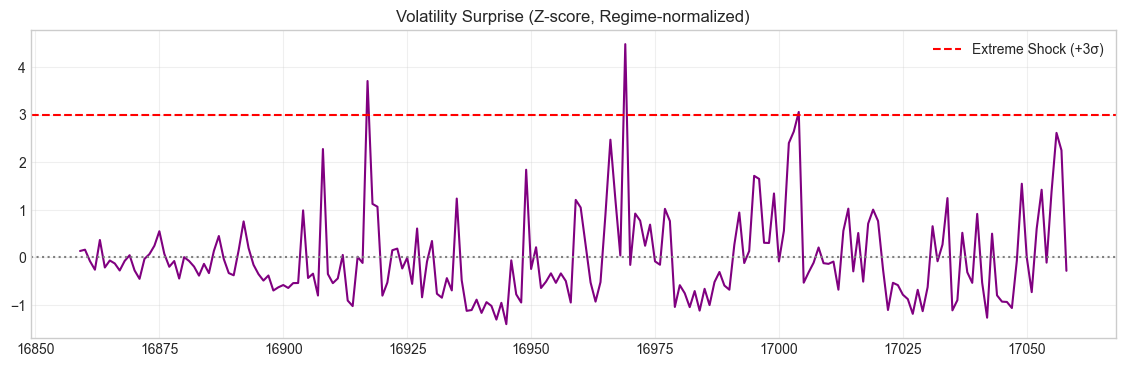

In [22]:
roll_mean_50 = master_df['vol_gk'].rolling(50).mean().shift(1)
roll_std_50  = master_df['vol_gk'].rolling(50).std().shift(1)

master_df['vol_gk_z'] = (
    (master_df['vol_gk'] - roll_mean_50) / (roll_std_50 + EPS)
)

subset = master_df.iloc[-200:].copy()

plt.figure(figsize=(14, 4))
plt.plot(subset.index, subset['vol_gk_z'], color='purple')
plt.axhline(3, color='red', ls='--', label='Extreme Shock (+3σ)')
plt.axhline(0, color='gray', ls=':')
plt.title('Volatility Surprise (Z-score, Regime-normalized)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

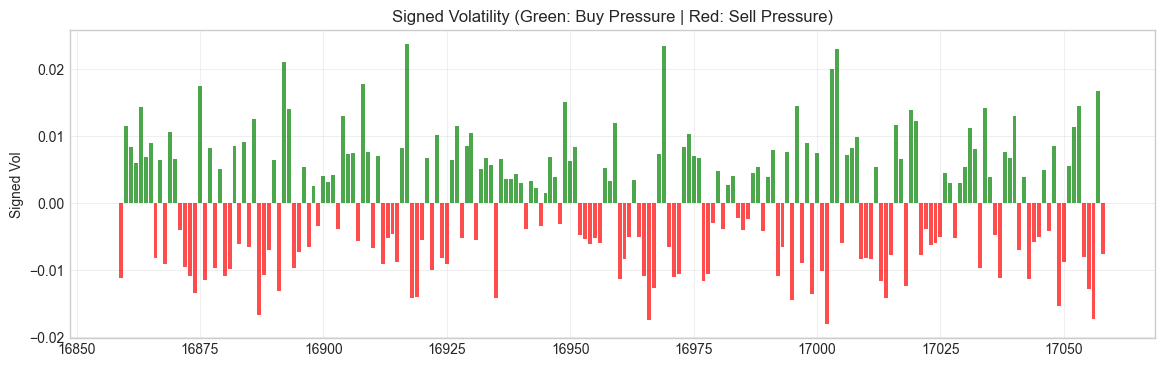

In [23]:
master_df['vol_signed'] = (
    master_df['vol_gk'] * np.sign(master_df['BTC_log_return'])
)

subset = master_df.iloc[-200:].copy()

colors = np.where(subset['vol_signed'] >= 0, 'green', 'red')

plt.figure(figsize=(14, 4))
plt.bar(subset.index, subset['vol_signed'], color=colors, alpha=0.7)
plt.title('Signed Volatility (Green: Buy Pressure | Red: Sell Pressure)')
plt.ylabel('Signed Vol')
plt.grid(alpha=0.3)
plt.show()

In [24]:
final_features.extend(["vol_gk", "vol_gk_z", "vol_signed"])

<cell_type>markdown</cell_type>
### Microstructure features - Candlestick dynamics

In [25]:
rng = master_df['BTC_high'] - master_df['BTC_low']
body = np.abs(master_df['BTC_close'] - master_df['BTC_open'])
upper_wick = master_df['BTC_high'] - np.maximum(master_df['BTC_close'], master_df['BTC_open'])
lower_wick = np.minimum(master_df['BTC_close'], master_df['BTC_open']) - master_df['BTC_low']

In [26]:
# Close location value (CLV)
master_df['clv'] = np.where(
    rng > EPS,
    ((master_df['BTC_close'] - master_df['BTC_low']) - (master_df['BTC_high'] - master_df['BTC_close'])) / rng,
    0.0
)

In [27]:
# Shadow ratios
master_df['upper_wick_ratio'] = upper_wick / (rng + EPS)
master_df['lower_wick_ratio'] = lower_wick / (rng + EPS)

# Wick imbalance
master_df['wick_imbalance'] = (upper_wick - lower_wick) / (rng + EPS)

/var/folders/h3/4_pq_7pd3pq2286xkp78c1480000gn/T/ipykernel_96863/1495510078.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x='clv_bin', y='debug_next_return', palette='RdYlGn', errorbar=None)


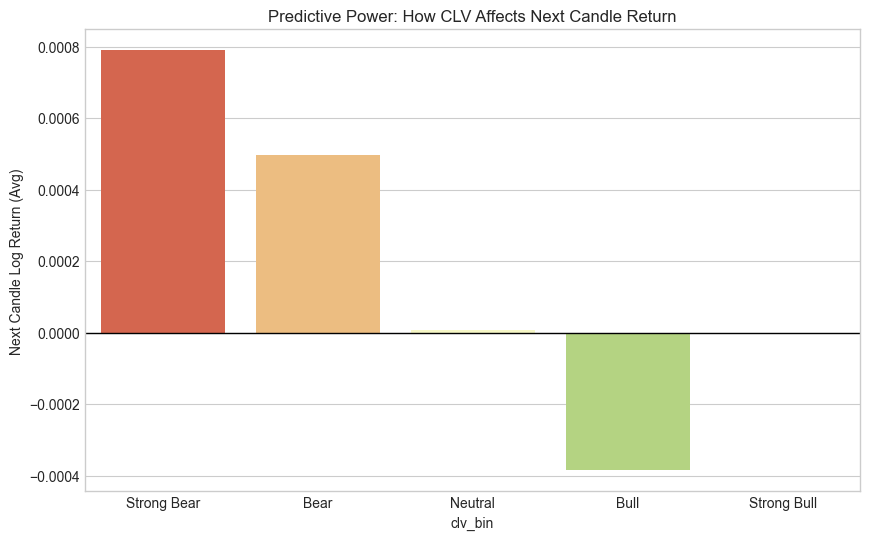

In [28]:
master_df['debug_next_return'] = master_df['BTC_log_return'].shift(-1)

master_df['clv_bin'] = pd.cut(master_df['clv'], bins=5, labels=['Strong Bear', 'Bear', 'Neutral', 'Bull', 'Strong Bull'])

plt.figure(figsize=(10, 6))
sns.barplot(data=master_df, x='clv_bin', y='debug_next_return', palette='RdYlGn', errorbar=None)
plt.axhline(0, color='black', lw=1)
plt.title('Predictive Power: How CLV Affects Next Candle Return')
plt.ylabel('Next Candle Log Return (Avg)')
plt.show()

master_df.drop(columns=['debug_next_return', 'clv_bin'], inplace=True)

In [29]:
final_features.extend(["clv", "wick_imbalance"])

### Technical indicators

In [30]:
window = 20

ma20_shifted  = master_df['BTC_close'].rolling(window).mean().shift(1)
std20_shifted = master_df['BTC_close'].rolling(window).std().shift(1)

master_df['bb_upper'] = ma20_shifted + 2 * std20_shifted
master_df['bb_lower'] = ma20_shifted - 2 * std20_shifted

In [31]:
master_df['bb_pct_b'] = (master_df['BTC_close'] - master_df['bb_lower']) / ((master_df['bb_upper'] - master_df['bb_lower']) + EPS)
master_df['bb_width'] = (master_df['bb_upper'] - master_df['bb_lower']) / (ma20_shifted + EPS)

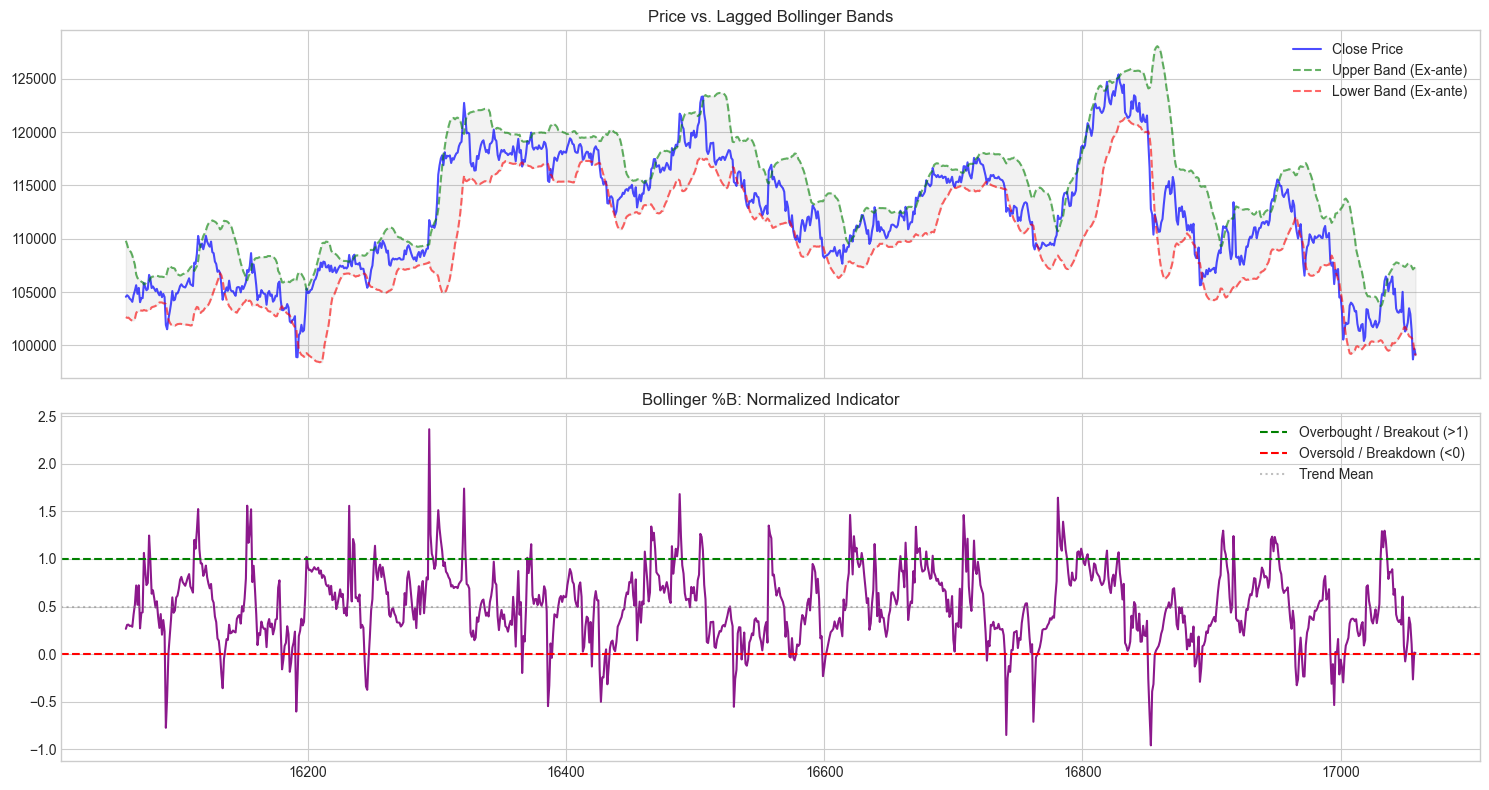

In [32]:
subset = master_df.iloc[-1000:].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Price and Bands (lagged)
axes[0].plot(subset.index, subset['BTC_close'], label='Close Price', color='blue', alpha=0.7)
axes[0].plot(subset.index, subset['bb_upper'], color='green', linestyle='--', alpha=0.6, label='Upper Band (Ex-ante)')
axes[0].plot(subset.index, subset['bb_lower'], color='red', linestyle='--', alpha=0.6, label='Lower Band (Ex-ante)')
axes[0].fill_between(subset.index, subset['bb_upper'], subset['bb_lower'], color='gray', alpha=0.1)
axes[0].set_title('Price vs. Lagged Bollinger Bands')
axes[0].legend()

# %B (Stationary)
axes[1].plot(subset.index, subset['bb_pct_b'], color='purple', alpha=0.9)
axes[1].axhline(1, color='green', ls='--', label='Overbought / Breakout (>1)')
axes[1].axhline(0, color='red', ls='--', label='Oversold / Breakdown (<0)')
axes[1].axhline(0.5, color='gray', ls=':', alpha=0.5, label='Trend Mean')
axes[1].set_title('Bollinger %B: Normalized Indicator')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

master_df.drop(columns=['bb_upper', 'bb_lower'], inplace=True)

In [33]:
final_features.extend(["bb_pct_b", "bb_width"])

### Inter-market correlation

In [34]:
# Rolling Correlation: BTC vs ETH
window = 30 * 6  # 30 days

master_df['btc_eth_corr'] = (
    master_df['BTC_log_return']
    .rolling(window)
    .corr(master_df['ETH_log_return'])
)

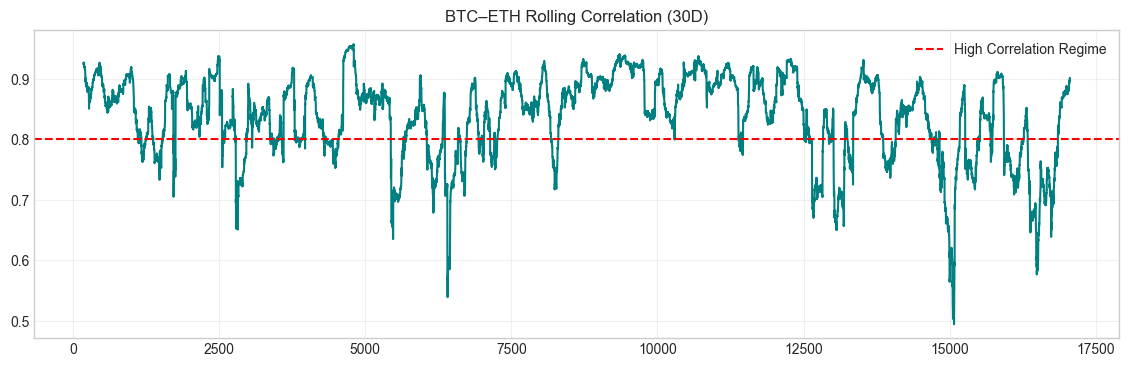

In [35]:
plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['btc_eth_corr'], color='teal')
plt.axhline(0.8, color='red', ls='--', label='High Correlation Regime')
plt.title('BTC–ETH Rolling Correlation (30D)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [36]:
final_features.extend(["btc_eth_corr"])

### Quote volume and trades

In [37]:
# Average Ticket Size (USDT)
master_df['ats'] = (
    master_df['BTC_quote_volume'] /
    (master_df['BTC_trades'] + EPS)
)

# Relative ATS (Ex-ante, Stationary)
master_df['ats_ma20'] = master_df['ats'].rolling(20).mean().shift(1)
master_df['rel_ats'] = master_df['ats'] / (master_df['ats_ma20'] + EPS)

# Log transform (Model-ready)
master_df['log_rel_ats'] = np.log(master_df['rel_ats'] + EPS)

# Trade Count Momentum (Stationary)
master_df['trades_log_return'] = np.log(
    master_df['BTC_trades'] /
    master_df['BTC_trades'].shift(1)
)

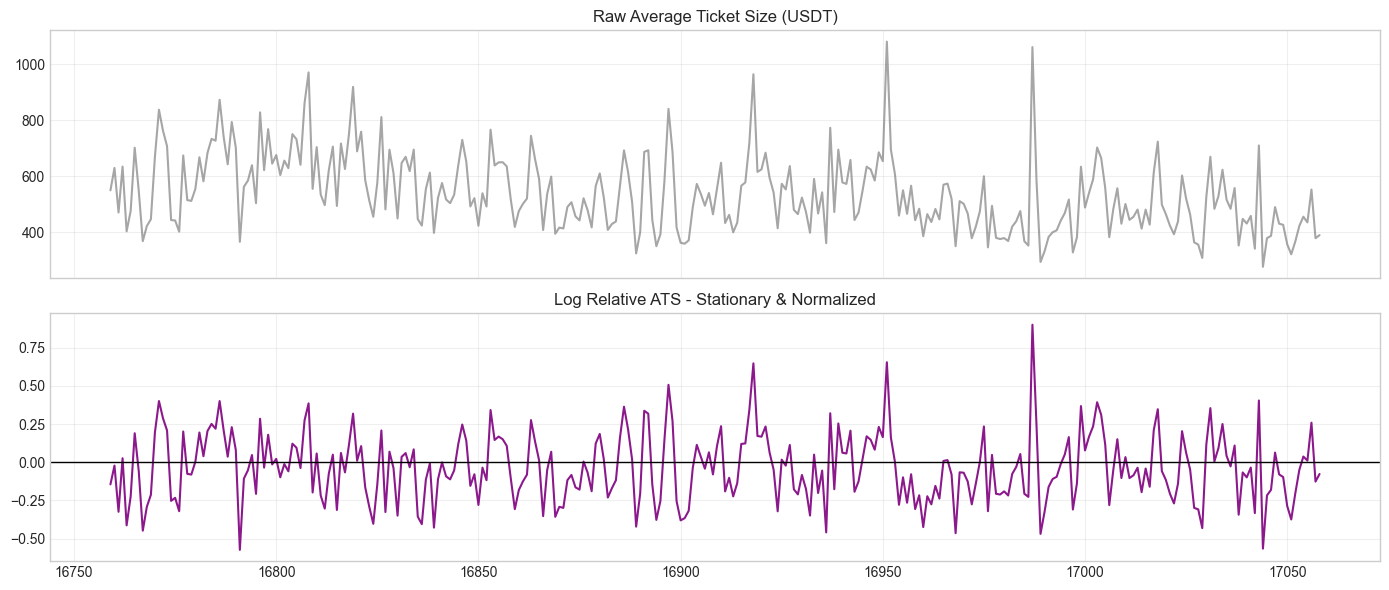

In [38]:
subset = master_df.iloc[-300:].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Raw ATS (scale-dependent, trending)
axes[0].plot(subset.index, subset['ats'], color='gray', alpha=0.7)
axes[0].set_title('Raw Average Ticket Size (USDT)')
axes[0].grid(alpha=0.3)

# Log Relative ATS (stationary, model-friendly)
axes[1].plot(subset.index, subset['log_rel_ats'], color='purple', alpha=0.9)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Log Relative ATS - Stationary & Normalized')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

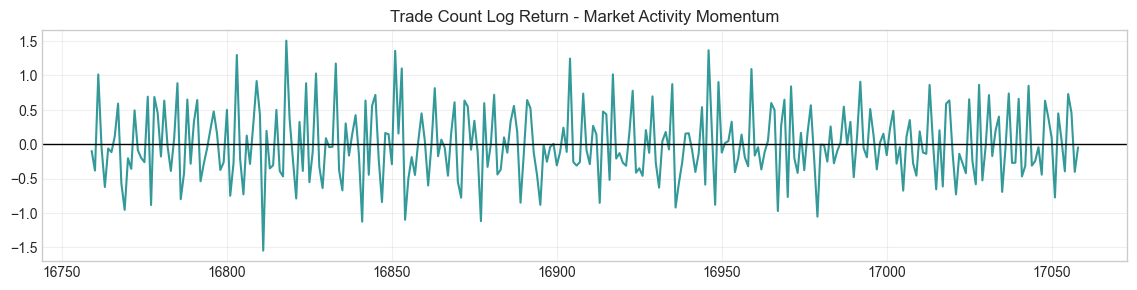

In [39]:
plt.figure(figsize=(14, 3))
plt.plot(subset.index, subset['trades_log_return'], color='teal', alpha=0.8)
plt.axhline(0, color='black', lw=1)
plt.title('Trade Count Log Return - Market Activity Momentum')
plt.grid(alpha=0.3)
plt.show()

In [40]:
final_features.extend(["log_rel_ats", "trades_log_return"])

## Market cap

In [41]:
mcap_cols = [
    'BTC_market_cap',
    'ETH_market_cap',
    'USDT_market_cap',
    'USDC_market_cap'
]

mcap_df = master_df[
    ['timestamp', 'BTC_close', 'BTC_log_return'] + mcap_cols
].copy()

mcap_df.dropna(inplace=True)
mcap_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17058 entries, 1 to 17058
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        17058 non-null  datetime64[ns]
 1   BTC_close        17058 non-null  float64       
 2   BTC_log_return   17058 non-null  float64       
 3   BTC_market_cap   17058 non-null  float64       
 4   ETH_market_cap   17058 non-null  float64       
 5   USDT_market_cap  17058 non-null  float64       
 6   USDC_market_cap  17058 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.0 MB


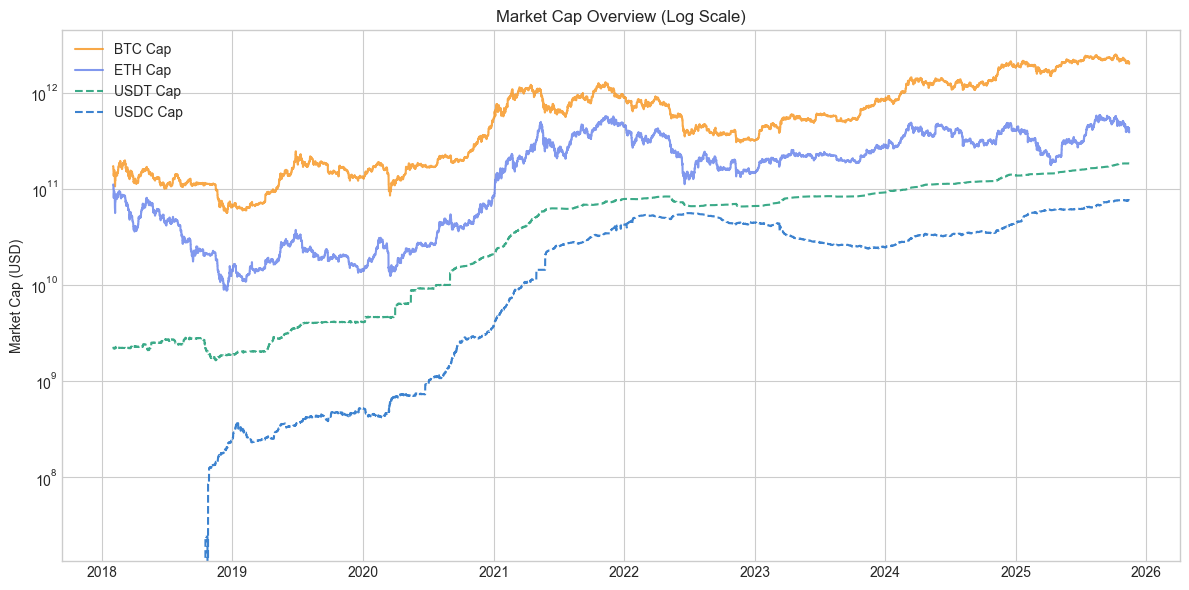

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(mcap_df['timestamp'], mcap_df['BTC_market_cap'],
        label='BTC Cap', color='#F7931A', alpha=0.8)

ax.plot(mcap_df['timestamp'], mcap_df['ETH_market_cap'],
        label='ETH Cap', color='#627EEA', alpha=0.8)

ax.plot(mcap_df['timestamp'], mcap_df['USDT_market_cap'],
        label='USDT Cap', color='#26A17B', ls='--', alpha=0.9)

ax.plot(mcap_df['timestamp'], mcap_df['USDC_market_cap'],
        label='USDC Cap', color='#2775CA', ls='--', alpha=0.9)

ax.set_yscale('log')
ax.set_title('Market Cap Overview (Log Scale)')
ax.set_ylabel('Market Cap (USD)')
ax.legend()

plt.tight_layout()
plt.show()

In [43]:
# Total stablecoin liquidity (dry powder)
mcap_df['total_stable_cap'] = (
    mcap_df['USDT_market_cap'] +
    mcap_df['USDC_market_cap']
)

# Stablecoin supply momentum (stationary)
mcap_df['stable_supply_change'] = np.log(
    mcap_df['total_stable_cap'] /
    mcap_df['total_stable_cap'].shift(1)
)

In [44]:
# SSR ratio (level)
mcap_df['ssr_ratio'] = (
    mcap_df['BTC_market_cap'] /
    (mcap_df['total_stable_cap'] + 1e-8)
)

# Dynamic change in buying power
mcap_df['ssr_log_change'] = np.log(
    mcap_df['ssr_ratio'] /
    mcap_df['ssr_ratio'].shift(1)
)

# SSR oscillator (regime-based)
roll_mean_90 = mcap_df['ssr_ratio'].rolling(90).mean()
roll_std_90  = mcap_df['ssr_ratio'].rolling(90).std()

mcap_df['ssr_z_score'] = (
    (mcap_df['ssr_ratio'] - roll_mean_90) /
    (roll_std_90 + 1e-8)
)

In [45]:
local_total_cap = (
    mcap_df['BTC_market_cap'] +
    mcap_df['ETH_market_cap'] +
    mcap_df['total_stable_cap']
)

mcap_df['btc_dom']  = mcap_df['BTC_market_cap'] / local_total_cap
mcap_df['usdt_dom'] = mcap_df['USDT_market_cap'] / local_total_cap

# Stationarize dominance
mcap_df['btc_dom_change']  = mcap_df['btc_dom'].diff()
mcap_df['usdt_dom_change'] = mcap_df['usdt_dom'].diff()

mcap_df.dropna(inplace=True)

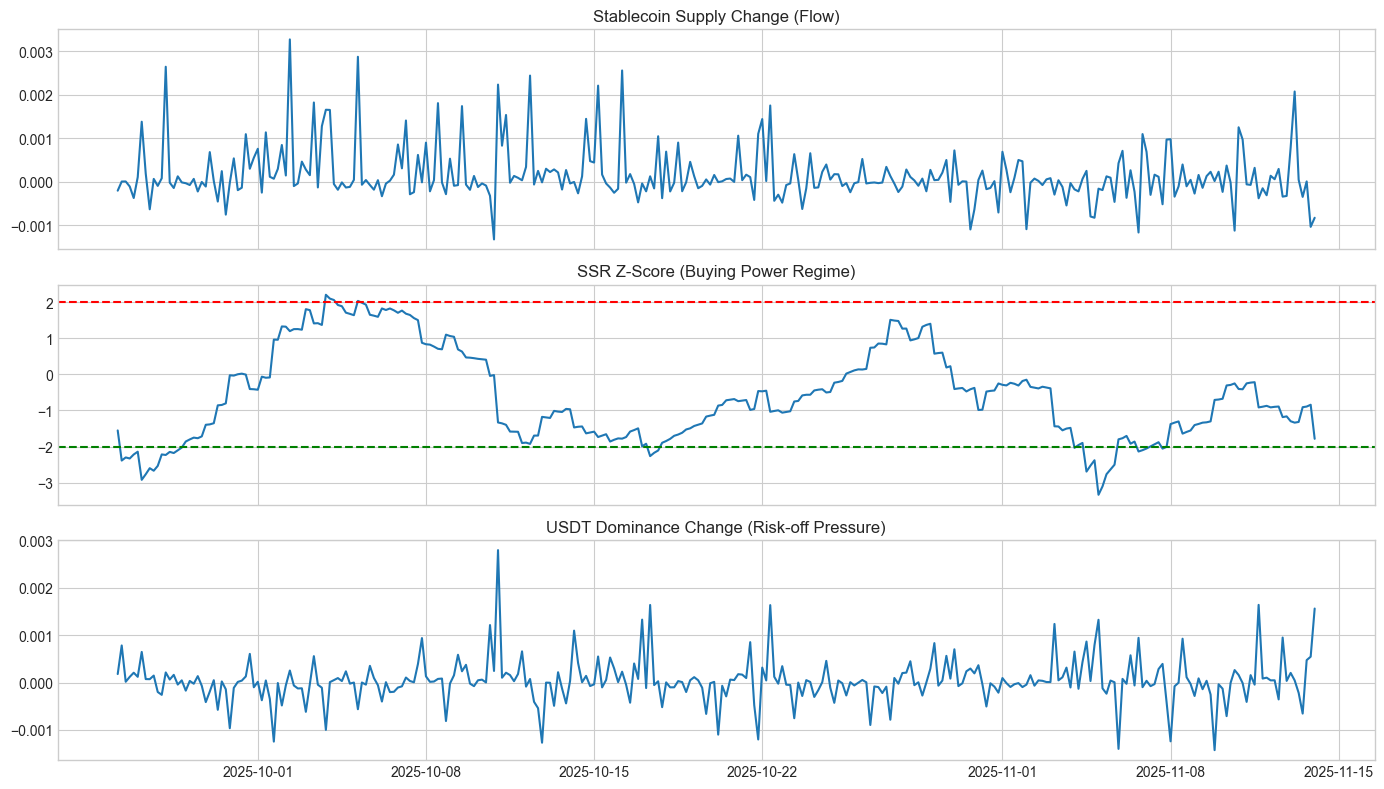

In [46]:
subset = mcap_df.iloc[-300:]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(subset['timestamp'], subset['stable_supply_change'])
axes[0].set_title('Stablecoin Supply Change (Flow)')

axes[1].plot(subset['timestamp'], subset['ssr_z_score'])
axes[1].axhline(2, ls='--', color='red')
axes[1].axhline(-2, ls='--', color='green')
axes[1].set_title('SSR Z-Score (Buying Power Regime)')

axes[2].plot(subset['timestamp'], subset['usdt_dom_change'])
axes[2].set_title('USDT Dominance Change (Risk-off Pressure)')

plt.tight_layout()
plt.show()


In [47]:
final_features.extend(["stable_supply_change", "ssr_z_score", "usdt_dom_change"])
master_df = master_df.merge(
    mcap_df[
        ['timestamp', 'stable_supply_change', 'ssr_z_score', 'usdt_dom_change']
    ],
    on='timestamp',
    how='left'
)

## Network activity

In [48]:
network_df = master_df[
    [
        'timestamp',
        'BTC_close',
        'BTC_log_return',
        'BTC_active_addresses',
        'BTC_tx_count'
    ]
].copy()

network_df.dropna(inplace=True)
network_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17058 entries, 1 to 17058
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             17058 non-null  datetime64[ns]
 1   BTC_close             17058 non-null  float64       
 2   BTC_log_return        17058 non-null  float64       
 3   BTC_active_addresses  17058 non-null  float64       
 4   BTC_tx_count          17058 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 799.6 KB


In [49]:
# 1. Network growth (log momentum)
network_df['addr_log_growth'] = np.log(
    network_df['BTC_active_addresses'] /
    network_df['BTC_active_addresses'].shift(1)
)

# 2. Transaction intensity (Tx per active user)
network_df['tx_per_user'] = (
    network_df['BTC_tx_count'] /
    (network_df['BTC_active_addresses'] + 1e-8)
)

network_df['log_tx_per_user'] = np.log(network_df['tx_per_user'])

# Stationarize intensity
network_df['intensity_change'] = network_df['log_tx_per_user'].diff()

In [50]:
network_df['price_to_addr_ratio'] = (
    network_df['BTC_close'] /
    (network_df['BTC_active_addresses'] + 1e-8)
)

roll_mean_90 = network_df['price_to_addr_ratio'].rolling(90).mean()
roll_std_90  = network_df['price_to_addr_ratio'].rolling(90).std()

network_df['network_valuation_z'] = (
    (network_df['price_to_addr_ratio'] - roll_mean_90) /
    (roll_std_90 + 1e-8)
)

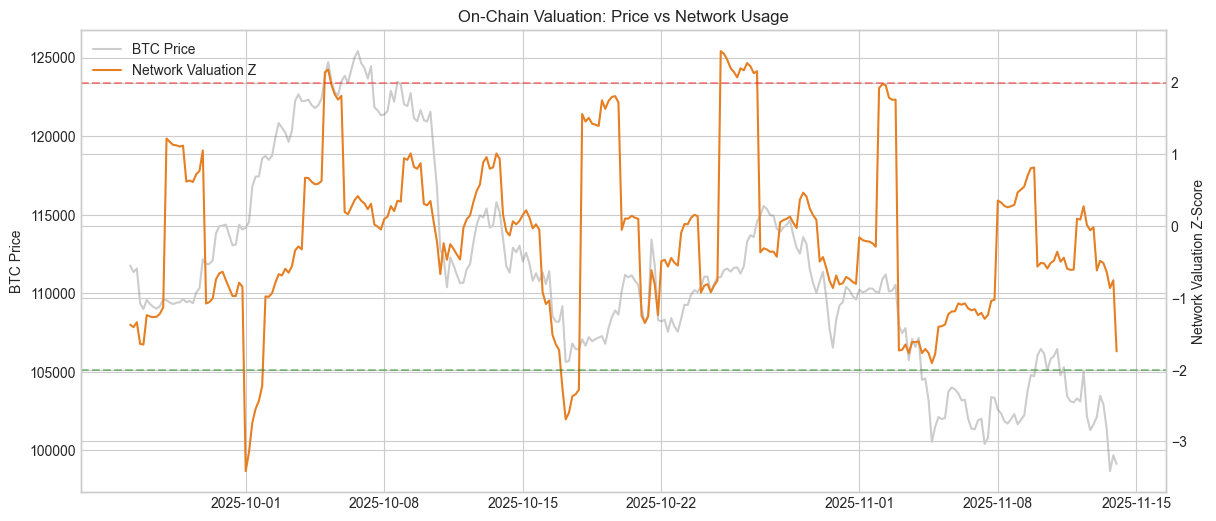

In [51]:
subset = network_df.iloc[-300:].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(subset['timestamp'], subset['BTC_close'],
         color='gray', alpha=0.4, label='BTC Price')
ax1.set_ylabel('BTC Price')

ax2 = ax1.twinx()
ax2.plot(subset['timestamp'], subset['network_valuation_z'],
         color='#e67e22', lw=1.5, label='Network Valuation Z')

ax2.axhline(2, color='red', ls='--', alpha=0.4)
ax2.axhline(-2, color='green', ls='--', alpha=0.4)
ax2.set_ylabel('Network Valuation Z-Score')

plt.title('On-Chain Valuation: Price vs Network Usage')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

In [52]:
final_features.extend(["addr_log_growth", "intensity_change", "network_valuation_z"])
master_df = master_df.merge(
    network_df[
        ['timestamp', 'addr_log_growth', 'intensity_change', 'network_valuation_z']
    ],
    on='timestamp',
    how='left'
)

## Secure and mining

In [53]:
mining_df = master_df[
    [
        'timestamp',
        'BTC_close',
        'BTC_log_return',
        'mining_difficulty',
        'hash_rate_ths',
        'miner_revenue_usd'
    ]
].copy()

mining_df.dropna(inplace=True)
mining_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17058 entries, 1 to 17058
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          17058 non-null  datetime64[ns]
 1   BTC_close          17058 non-null  float64       
 2   BTC_log_return     17058 non-null  float64       
 3   mining_difficulty  17058 non-null  float64       
 4   hash_rate_ths      17058 non-null  float64       
 5   miner_revenue_usd  17058 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 932.9 KB


In [54]:
mining_df['hash_ma30'] = mining_df['hash_rate_ths'].rolling(30).mean()
mining_df['hash_ma60'] = mining_df['hash_rate_ths'].rolling(60).mean()

# Stationary ribbon spread
mining_df['hash_ribbon_spread'] = (
    (mining_df['hash_ma30'] - mining_df['hash_ma60']) /
    (mining_df['hash_ma60'] + EPS)
)

In [55]:
mining_df['rev_ma365'] = mining_df['miner_revenue_usd'].rolling(365).mean()

mining_df['puell_multiple'] = (
    mining_df['miner_revenue_usd'] /
    (mining_df['rev_ma365'] + EPS)
)

# Log transform for model
mining_df['log_puell'] = np.log(mining_df['puell_multiple'] + EPS)

In [56]:
# Hashprice: USD earned per TH/s
mining_df['hashprice'] = (
    mining_df['miner_revenue_usd'] /
    (mining_df['hash_rate_ths'] + EPS)
)

# Stationarize hashprice
mining_df['hashprice_change'] = np.log(
    mining_df['hashprice'] /
    mining_df['hashprice'].shift(1)
)

# Difficulty adjustment pressure
mining_df['diff_change_pct'] = mining_df['mining_difficulty'].pct_change()

mining_df.dropna(inplace=True)

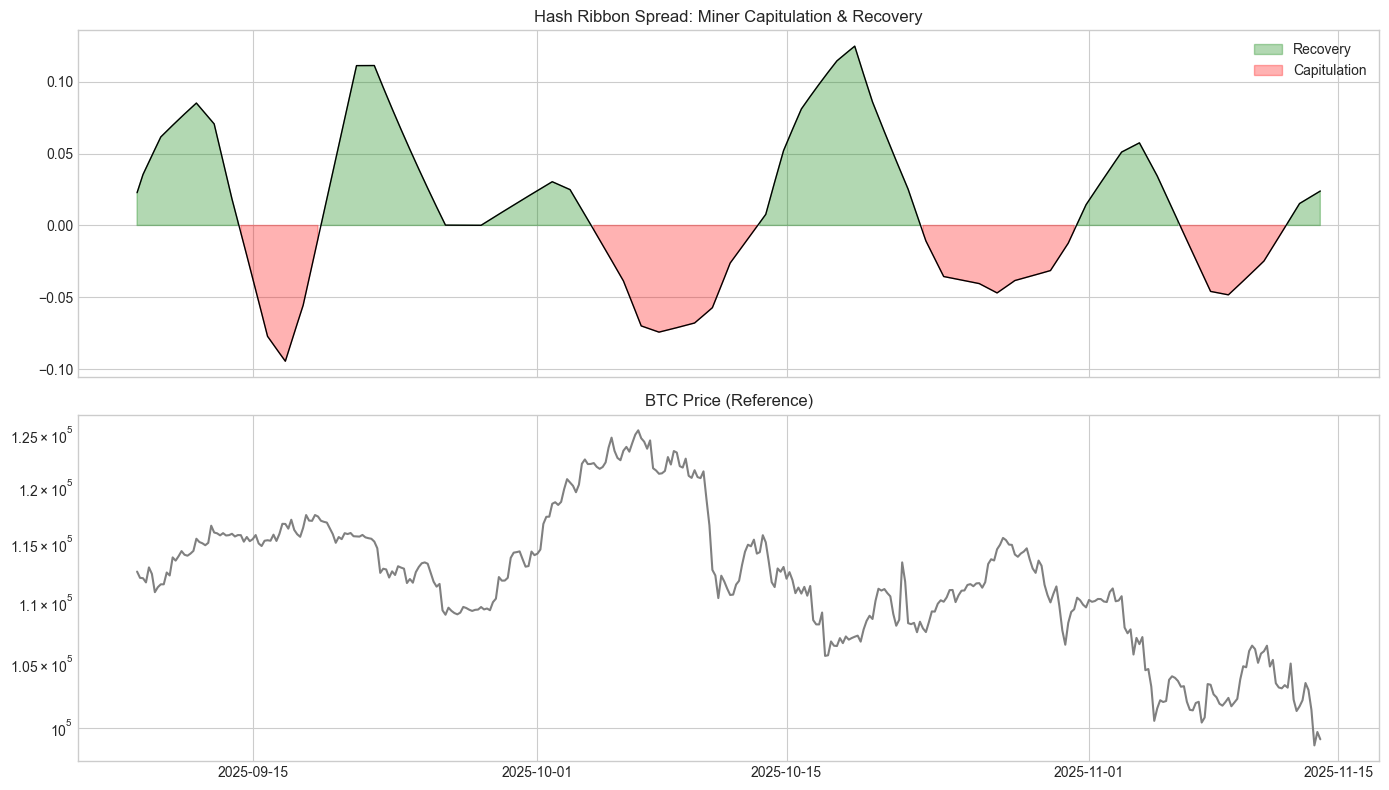

In [57]:
subset = mining_df.iloc[-400:].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Hash ribbon spread
axes[0].fill_between(
    subset['timestamp'], 0, subset['hash_ribbon_spread'],
    where=(subset['hash_ribbon_spread'] >= 0),
    color='green', alpha=0.3, label='Recovery'
)
axes[0].fill_between(
    subset['timestamp'], 0, subset['hash_ribbon_spread'],
    where=(subset['hash_ribbon_spread'] < 0),
    color='red', alpha=0.3, label='Capitulation'
)
axes[0].plot(subset['timestamp'], subset['hash_ribbon_spread'], color='black', lw=1)
axes[0].set_title('Hash Ribbon Spread: Miner Capitulation & Recovery')
axes[0].legend()

# BTC price reference
axes[1].plot(subset['timestamp'], subset['BTC_close'], color='gray')
axes[1].set_yscale('log')
axes[1].set_title('BTC Price (Reference)')

plt.tight_layout()
plt.show()

In [58]:
final_features.extend(["hash_ribbon_spread", "log_puell"])
master_df = master_df.merge(
    mining_df[
        ['timestamp', 'hash_ribbon_spread', 'log_puell']
    ],
    on='timestamp',
    how='left'
)

## Onchain Metrics

In [59]:
onchain_cols = [
    'BTC_onchain_total_supply',
    'BTC_onchain_mvrv_ratio',
    'BTC_onchain_exchange_inflow_usd',
    'BTC_onchain_exchange_outflow_usd',
    'BTC_onchain_exchange_supply_native'
]

onchain_df = master_df[
    ['timestamp', 'BTC_close', 'BTC_log_return'] + onchain_cols
].copy()

onchain_df.dropna(inplace=True)
onchain_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17058 entries, 1 to 17058
Data columns (total 8 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   timestamp                           17058 non-null  datetime64[ns]
 1   BTC_close                           17058 non-null  float64       
 2   BTC_log_return                      17058 non-null  float64       
 3   BTC_onchain_total_supply            17058 non-null  float64       
 4   BTC_onchain_mvrv_ratio              17058 non-null  float64       
 5   BTC_onchain_exchange_inflow_usd     17058 non-null  float64       
 6   BTC_onchain_exchange_outflow_usd    17058 non-null  float64       
 7   BTC_onchain_exchange_supply_native  17058 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.2 MB


In [60]:
roll_mean_mvrv = onchain_df['BTC_onchain_mvrv_ratio'].rolling(730).mean()
roll_std_mvrv  = onchain_df['BTC_onchain_mvrv_ratio'].rolling(730).std()

onchain_df['onchain_mvrv_z'] = (
    (onchain_df['BTC_onchain_mvrv_ratio'] - roll_mean_mvrv) /
    (roll_std_mvrv + EPS)
)

In [61]:
onchain_df['netflow_usd'] = (
    onchain_df['BTC_onchain_exchange_inflow_usd'] -
    onchain_df['BTC_onchain_exchange_outflow_usd']
)

nf_mean = onchain_df['netflow_usd'].rolling(30).mean()
nf_std  = onchain_df['netflow_usd'].rolling(30).std()

onchain_df['onchain_netflow_z'] = (
    (onchain_df['netflow_usd'] - nf_mean) /
    (nf_std + EPS)
)

In [62]:
onchain_df['exchange_reserve_ratio'] = (
    onchain_df['BTC_onchain_exchange_supply_native'] /
    (onchain_df['BTC_onchain_total_supply'] + EPS)
)

# Stationary change
onchain_df['reserve_ratio_change'] = onchain_df['exchange_reserve_ratio'].diff()

onchain_df.dropna(inplace=True)

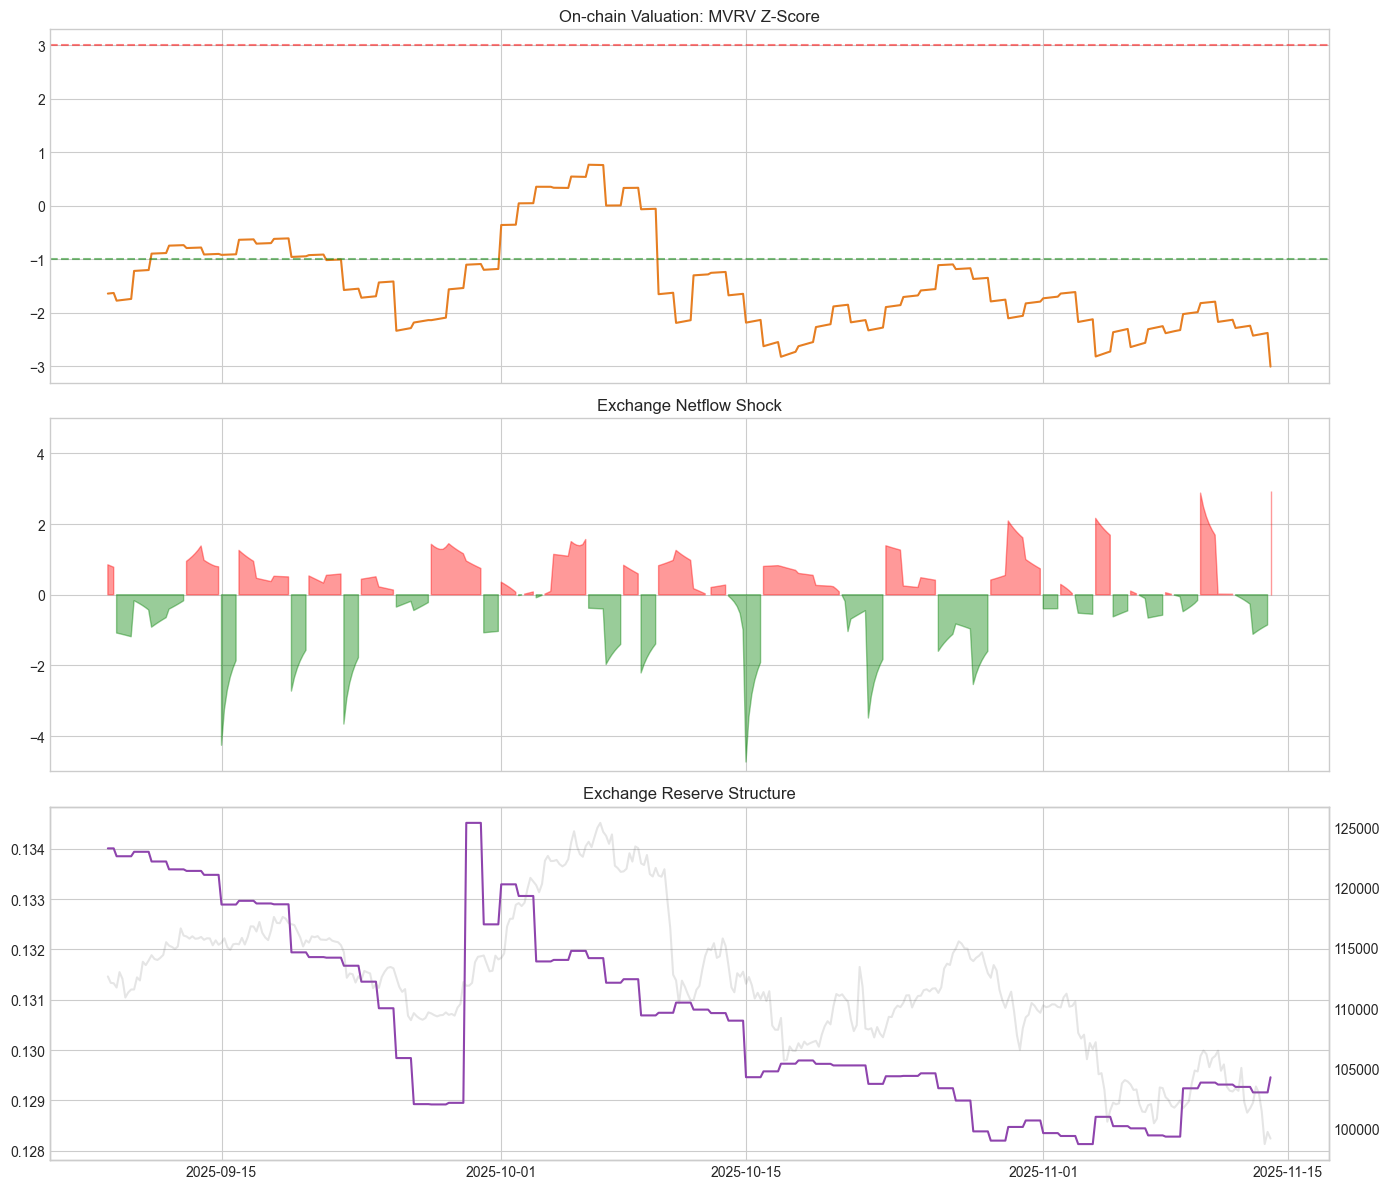

In [63]:
subset = onchain_df.iloc[-400:].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Valuation
axes[0].plot(subset['timestamp'], subset['onchain_mvrv_z'], color='#e67e22')
axes[0].axhline(3, ls='--', color='red', alpha=0.5)
axes[0].axhline(-1, ls='--', color='green', alpha=0.5)
axes[0].set_title('On-chain Valuation: MVRV Z-Score')

# Sell pressure
axes[1].fill_between(
    subset['timestamp'], 0, subset['onchain_netflow_z'],
    where=(subset['onchain_netflow_z'] > 0),
    color='red', alpha=0.4, label='Net Inflow'
)
axes[1].fill_between(
    subset['timestamp'], 0, subset['onchain_netflow_z'],
    where=(subset['onchain_netflow_z'] < 0),
    color='green', alpha=0.4, label='Net Outflow'
)
axes[1].set_ylim(-5, 5)
axes[1].set_title('Exchange Netflow Shock')

# Structure
ax3 = axes[2]
ax3.plot(subset['timestamp'], subset['exchange_reserve_ratio'],
         color='#8e44ad', label='Exchange Reserve Ratio')
ax3.set_title('Exchange Reserve Structure')

ax3_twin = ax3.twinx()
ax3_twin.plot(subset['timestamp'], subset['BTC_close'],
              color='gray', alpha=0.2)
ax3_twin.grid(False)

plt.tight_layout()
plt.show()

In [64]:
final_features.extend(["onchain_mvrv_z", "onchain_netflow_z", "reserve_ratio_change"])
master_df = master_df.merge(
    onchain_df[
        ['timestamp', 'onchain_mvrv_z', 'onchain_netflow_z', 'reserve_ratio_change']
    ],
    on='timestamp',
    how='left'
)

## News

In [65]:
news_cols = [
    'news_article_count',
    'news_combined_sent_mean',
    'news_head_exag_ratio'
]

news_df = master_df[
    ['timestamp', 'BTC_log_return', 'BTC_close'] + news_cols
].copy()

news_df.dropna(inplace=True)

# No-news logic
news_df.loc[news_df['news_article_count'] == 0, 'news_combined_sent_mean'] = 0.0
news_df['has_news'] = (news_df['news_article_count'] > 0).astype(int)

news_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17058 entries, 1 to 17058
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                17058 non-null  datetime64[ns]
 1   BTC_log_return           17058 non-null  float64       
 2   BTC_close                17058 non-null  float64       
 3   news_article_count       17058 non-null  float64       
 4   news_combined_sent_mean  17058 non-null  float64       
 5   news_head_exag_ratio     17058 non-null  float64       
 6   has_news                 17058 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 1.0 MB


In [66]:
news_df['news_impact_score'] = (
    news_df['news_combined_sent_mean'] *
    np.log1p(news_df['news_article_count'])
)

In [67]:
news_df['news_sentiment_decay_fast'] = (
    news_df['news_impact_score']
    .ewm(span=3, adjust=False)
    .mean()
)

news_df['news_sentiment_decay_slow'] = (
    news_df['news_impact_score']
    .ewm(span=6, adjust=False)
    .mean()
)

In [68]:
news_df['news_sentiment_shock'] = news_df['news_impact_score'].diff()

In [69]:
news_df['news_euphoria_level'] = news_df['news_impact_score'] ** 2

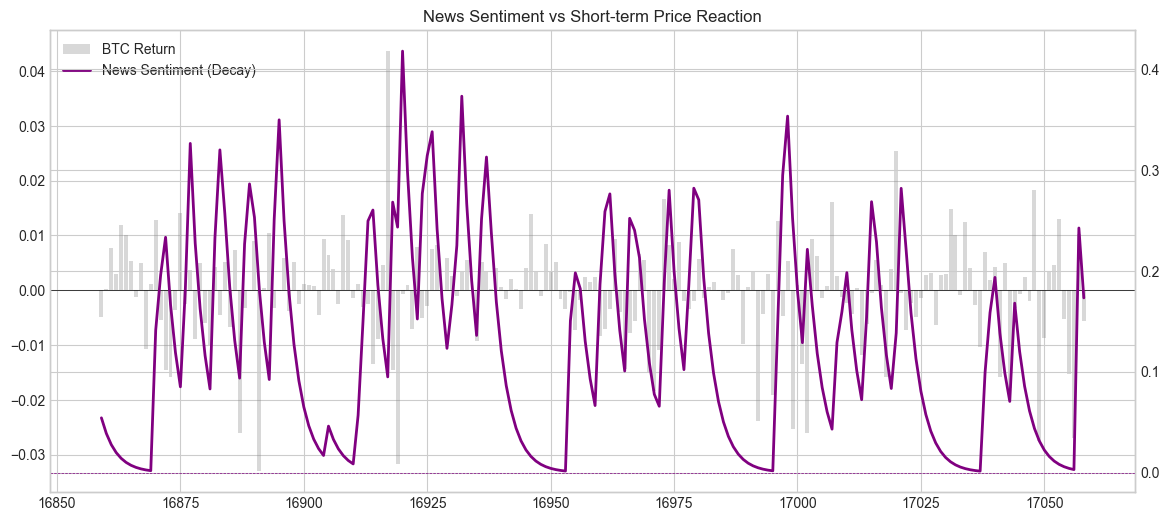

In [70]:
news_subset = news_df.iloc[-200:].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(news_subset.index, news_subset['BTC_log_return'],
        color='gray', alpha=0.3, label='BTC Return')
ax1.axhline(0, color='black', lw=0.5)

# News sentiment decay
ax2 = ax1.twinx()
ax2.plot(news_subset.index, news_subset['news_sentiment_decay_slow'],
         color='purple', lw=2, label='News Sentiment (Decay)')

ax1.set_title('News Sentiment vs Short-term Price Reaction')
ax2.axhline(0, color='purple', ls='--', lw=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

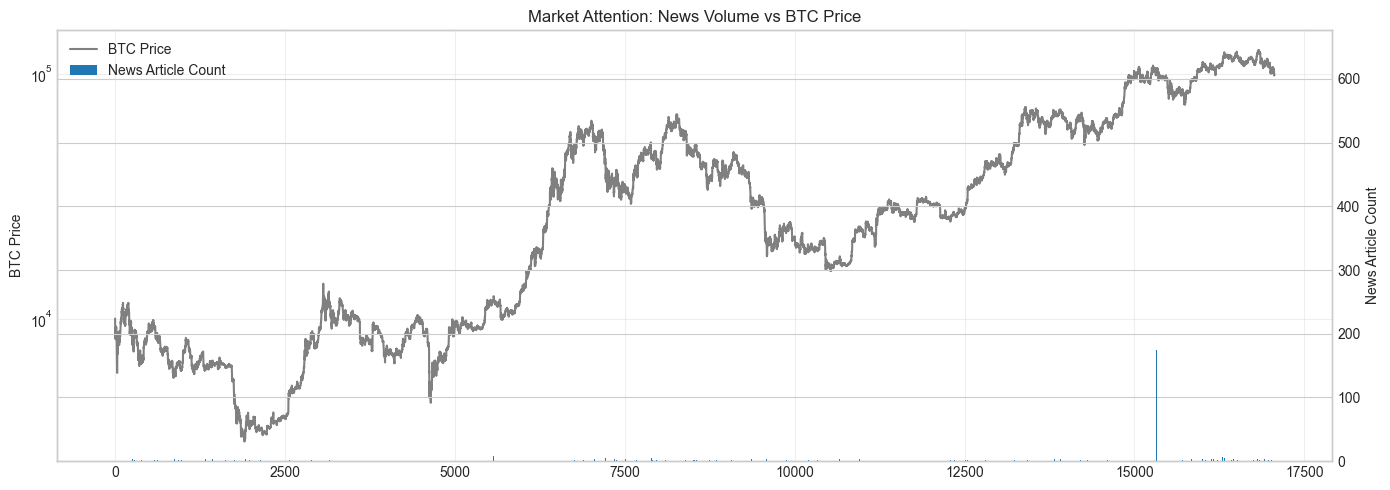

In [71]:
news_subset = news_df

fig, ax1 = plt.subplots(figsize=(14, 5))

# BTC Price (Context)
ax1.plot(
    news_subset.index,
    news_subset['BTC_close'],
    color='gray',
    alpha=1,
    label='BTC Price'
)
ax1.set_ylabel('BTC Price')
ax1.set_yscale('log')
ax1.grid(alpha=0.3)

# News Volume (Attention)
ax2 = ax1.twinx()
ax2.bar(
    news_subset.index,
    news_subset['news_article_count'],
    color='tab:blue',
    alpha=1,
    label='News Article Count'
)
ax2.set_ylabel('News Article Count')

# Title & Legend
ax1.set_title('Market Attention: News Volume vs BTC Price')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [72]:
final_features.extend(["news_article_count", "news_impact_score", "news_sentiment_decay_slow", "news_sentiment_shock"])
master_df = master_df.merge(
    news_df[
        ['timestamp', 'news_impact_score', 'news_sentiment_decay_slow', 'news_sentiment_shock']
    ],
    on='timestamp',
    how='left'
)

## Sentiment index

In [73]:
sent_cols = ['sentiment_index_value', 'sentiment_index_classification']

sent_df = master_df[
    ['timestamp', 'BTC_close', 'BTC_log_return'] + sent_cols
].copy()

sent_df.dropna(inplace=True)

print(f"Sentiment data shape: {sent_df.shape}")
sent_df.head()

Sentiment data shape: (17058, 5)


,timestamp,BTC_close,BTC_log_return,sentiment_index_value,sentiment_index_classification
1,2018-02-01 04:00:00,10063.75000,-0.00060,30.00000,Fear
2,2018-02-01 08:00:00,9591.44000,-0.04807,30.00000,Fear
3,2018-02-01 12:00:00,9339.87000,-0.02658,30.00000,Fear
4,2018-02-01 16:00:00,8941.94000,-0.04354,30.00000,Fear
5,2018-02-01 20:00:00,9224.52000,0.03111,30.00000,Fear


In [74]:
mapping = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
}

sent_df['sentiment_class_encoded'] = (
    sent_df['sentiment_index_classification']
    .map(mapping)
    .fillna(2)
)

sent_df['fng_change'] = sent_df['sentiment_index_value'].diff()

sent_df[['sentiment_index_value', 'fng_change']].describe()

,sentiment_index_value,fng_change
count,17058.00000,17057.00000
mean,47.59644,-0.00082
std,21.59005,2.67699
min,5.00000,-45.00000
25%,28.00000,0.00000
50%,48.00000,0.00000
75%,66.00000,0.00000
max,95.00000,40.00000


In [75]:
window_7d = 7 * 6  # 7 days

sent_df['fng_ma7'] = (
    sent_df['sentiment_index_value']
    .rolling(window_7d)
    .mean()
)

sent_df['fng_divergence'] = (
    sent_df['sentiment_index_value']
    - sent_df['fng_ma7']
)

In [76]:
sent_df['is_extreme_fear']  = (sent_df['sentiment_index_value'] <= 20).astype(int)
sent_df['is_extreme_greed'] = (sent_df['sentiment_index_value'] >= 80).astype(int)

sent_df['fng_bucket'] = pd.cut(
    sent_df['sentiment_index_value'],
    bins=[0, 20, 45, 55, 80, 100],
    labels=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
)

In [77]:
sent_df['next_return'] = sent_df['BTC_log_return'].shift(-1)
sent_df.dropna(inplace=True)

sent_df[['fng_change', 'fng_divergence', 'next_return']].head()

,fng_change,fng_divergence,next_return
42,-6.00000,6.57143,0.00793
43,0.00000,6.57143,0.00787
44,0.00000,6.57143,0.00781
45,0.00000,6.57143,0.00775
46,0.00000,6.57143,0.00769


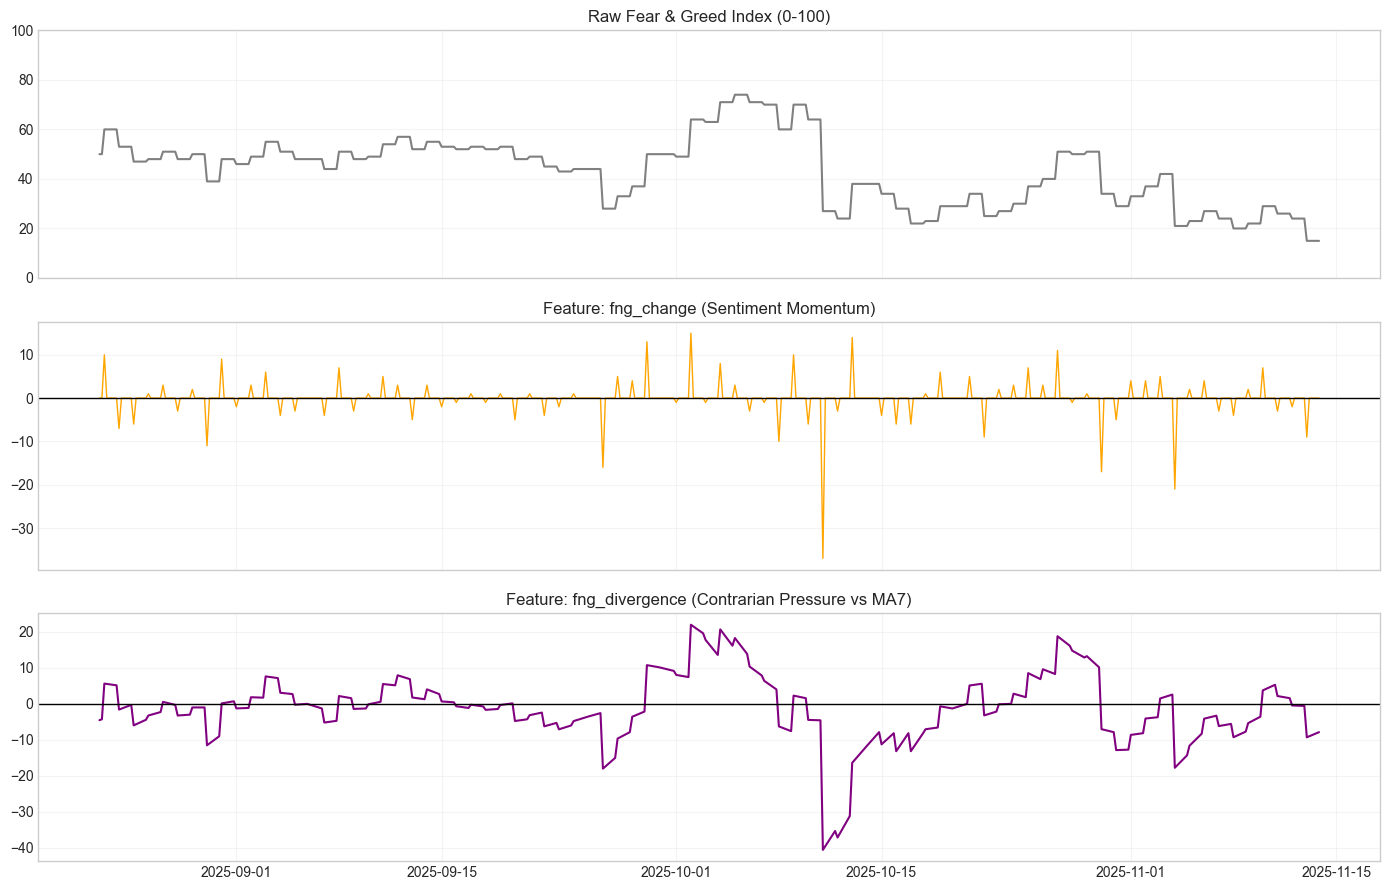

In [78]:
# Sentiment EDA: Raw vs Engineered Features
sent_subset = sent_df.iloc[-500:].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Raw Sentiment
axes[0].plot(sent_subset['timestamp'], sent_subset['sentiment_index_value'], color='gray', lw=1.5)
axes[0].set_title('Raw Fear & Greed Index (0-100)')
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.2)

# Momentum
axes[1].plot(sent_subset['timestamp'], sent_subset['fng_change'], color='orange', lw=1)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Feature: fng_change (Sentiment Momentum)')
axes[1].grid(alpha=0.2)

# Divergence
axes[2].plot(sent_subset['timestamp'], sent_subset['fng_divergence'], color='purple', lw=1.5)
axes[2].axhline(0, color='black', lw=1)
axes[2].set_title('Feature: fng_divergence (Contrarian Pressure vs MA7)')
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

/var/folders/h3/4_pq_7pd3pq2286xkp78c1480000gn/T/ipykernel_96863/3671992740.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sent_df, x='fng_bucket', y='abs_return', palette='coolwarm')


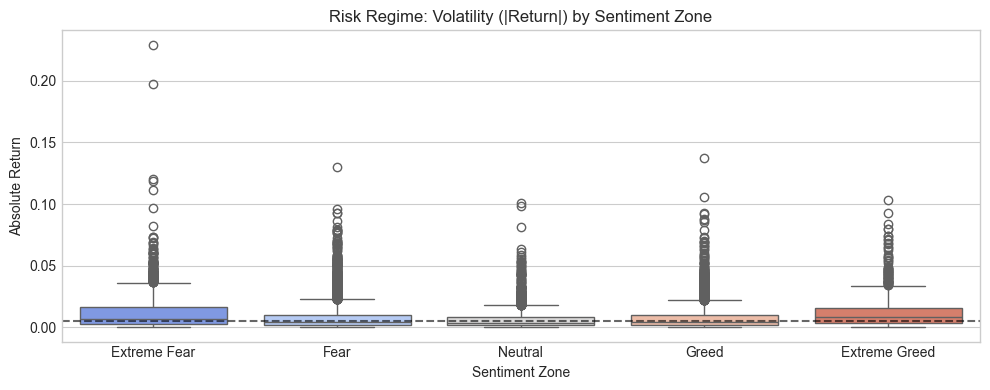

In [79]:
# Sentiment EDA: Risk Regime (Volatility)
sent_df['abs_return'] = sent_df['BTC_log_return'].abs()

plt.figure(figsize=(10, 4))
sns.boxplot(data=sent_df, x='fng_bucket', y='abs_return', palette='coolwarm')
plt.title('Risk Regime: Volatility (|Return|) by Sentiment Zone')
plt.xlabel('Sentiment Zone')
plt.ylabel('Absolute Return')
plt.axhline(sent_df['abs_return'].median(), color='black', ls='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [80]:
final_features.extend(["fng_change", "fng_divergence"])
master_df = master_df.merge(
    sent_df[
        ['timestamp', 'fng_change', 'fng_divergence']
    ],
    on='timestamp',
    how='left'
)

## Feature selection


In [81]:
final_df = master_df.copy()
final_df = final_df[['timestamp'] + final_features]
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17059 entries, 0 to 17058
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   timestamp                  17059 non-null  datetime64[ns]
 1   BTC_log_return             17058 non-null  float64       
 2   ETH_log_return             17058 non-null  float64       
 3   target                     17058 non-null  float64       
 4   BTC_vol_log_return         17058 non-null  float64       
 5   log_rvol                   17039 non-null  float64       
 6   vol_gk                     17059 non-null  float64       
 7   vol_gk_z                   17009 non-null  float64       
 8   vol_signed                 17058 non-null  float64       
 9   clv                        17059 non-null  float64       
 10  wick_imbalance             17059 non-null  float64       
 11  bb_pct_b                   17039 non-null  float64       
 12  bb_w

Total Infinite values found: 0

--- Top Columns with NaNs (Before Drop) ---
reserve_ratio_change    730
onchain_netflow_z       730
onchain_mvrv_z          730
log_puell               365
hash_ribbon_spread      365
btc_eth_corr            180
stable_supply_change     90
network_valuation_z      90
usdt_dom_change          90
ssr_z_score              90
dtype: int64

Original shape: (17059, 33)
Train-ready shape: (16328, 33)


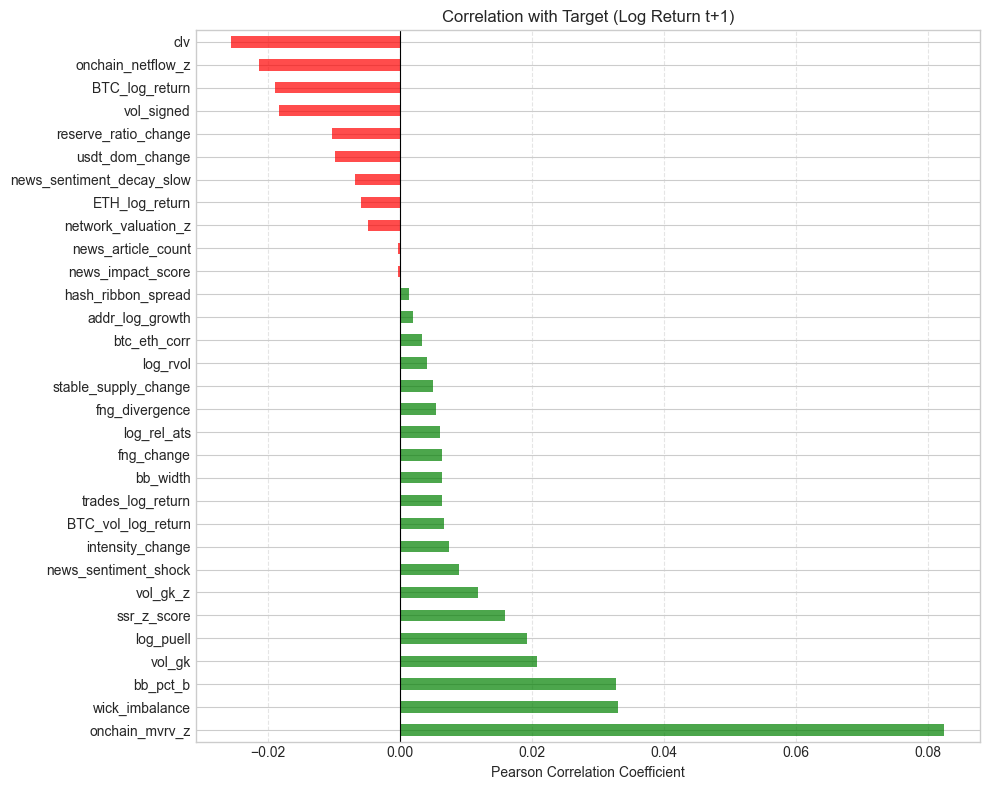


--- Top 5 Positively Correlated Features ---
onchain_mvrv_z   0.08251
wick_imbalance   0.03299
bb_pct_b         0.03280
vol_gk           0.02067
log_puell        0.01924
Name: target, dtype: float64

--- Top 5 Negatively Correlated Features ---
reserve_ratio_change   -0.01036
vol_signed             -0.01836
BTC_log_return         -0.01901
onchain_netflow_z      -0.02137
clv                    -0.02562
Name: target, dtype: float64


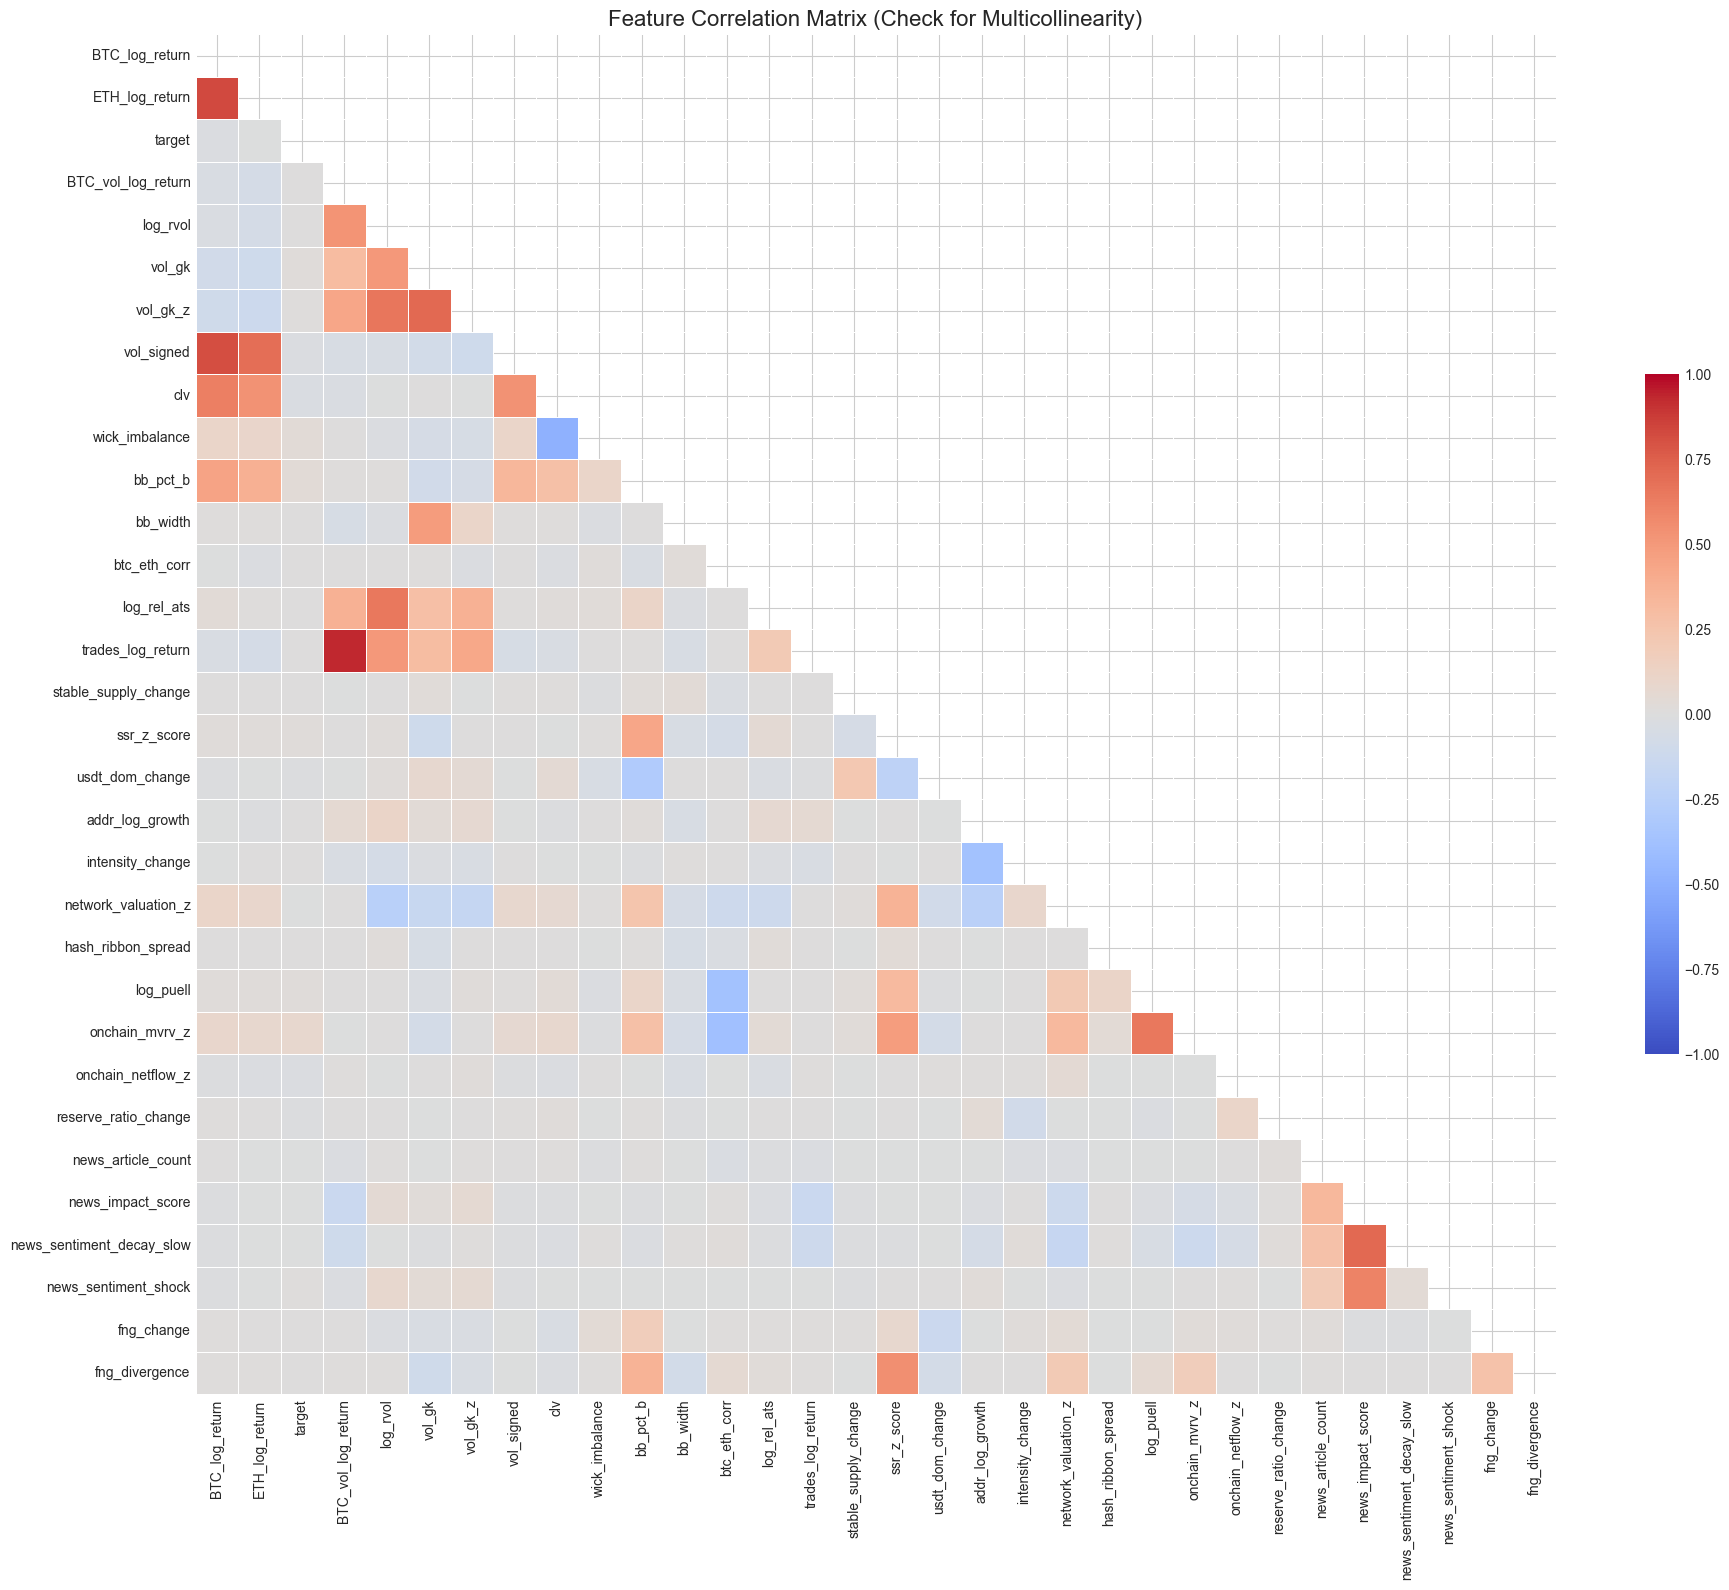


--- High Correlation Pairs (Potential Redundancy) ---
trades_log_return vs BTC_vol_log_return: 0.93


In [82]:
# %%
# ===== Sanity Check =====

# 1. Infinite Check
# Replace infinite values with NaN to handle them together
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

inf_count = np.isinf(final_df.drop(columns=['timestamp'])).sum().sum()
print(f"Total Infinite values found: {inf_count}")

# 2. Null Check (Expected behavior due to lag/rolling)
print("\n--- Top Columns with NaNs (Before Drop) ---")
print(final_df.isnull().sum().sort_values(ascending=False).head(10))

# 3. Clean Data for Training
# We drop NaNs created by the largest rolling window (e.g., mvrv rolling 730)
# and the last row (target is NaN)
train_ready_df = final_df.dropna()

print(f"\nOriginal shape: {final_df.shape}")
print(f"Train-ready shape: {train_ready_df.shape}")

# Verify no NaNs remain
assert train_ready_df.isnull().sum().sum() == 0, "Data still has NaNs!"

# %%
# ===== Correlation Analysis =====

# Compute correlation matrix (excluding timestamp)
corr_matrix = train_ready_df.drop(columns=['timestamp']).corr()

# 1. Feature vs Target Correlation
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
# Color logic: Green for positive corr, Red for negative
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, alpha=0.7)
plt.title("Correlation with Target (Log Return t+1)")
plt.xlabel("Pearson Correlation Coefficient")
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- Top 5 Positively Correlated Features ---")
print(target_corr.head(5))
print("\n--- Top 5 Negatively Correlated Features ---")
print(target_corr.tail(5))

# %%
# 2. Feature vs Feature Correlation (Multicollinearity Check)

plt.figure(figsize=(20, 16))

# Mask upper triangle to reduce visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    cmap='coolwarm', 
    center=0,
    vmax=1, 
    vmin=-1,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5},
    annot=False # Set True if you want numbers, but it will be messy with many features
)

plt.title('Feature Correlation Matrix (Check for Multicollinearity)', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detect high correlation pairs (> 0.9 or < -0.9)
print("\n--- High Correlation Pairs (Potential Redundancy) ---")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            print(f"{colname_i} vs {colname_j}: {corr_matrix.iloc[i, j]:.2f}")

In [83]:
print("Before cleaning:", final_df.shape)
final_df = final_df.dropna()
final_df = final_df.drop(columns=['trades_log_return'])
print("After cleaning:", final_df.shape)

Before cleaning: (17059, 33)
After cleaning: (16328, 32)


## To CSV

In [84]:
final_df.to_csv('data/processed/final.csv', index=False)
final_df.to_pickle('data/processed/final.pkl')
print("Processed feature set saved to 'data/processed/final.csv'")

Processed feature set saved to 'data/processed/final.csv'
